In [22]:
import os
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import astropy.units as u

from config.plotting import save_figure, set_plotting_defaults, Tab10
from config.units import Gauss, flux_unit
from spectrum_fit_electrons import SynchrotronSteadyStateFit
from config.settings import MCMC_ELECTRONS_SYNCH_STEADY, SPECTRUM_DIR, SYNCH_INTERP_DIR
from src.electron_timescales import synchrotron_timescale
from src.synchrotron_emission import electron_synchrotron_emission_power, electron_synchrotron_emission_luminosity

set_plotting_defaults()

In [23]:
nsteps, nwalkers = 400, 16
bfield = 6e-6 * Gauss
bvalue = bfield.value

data = pickle.load(open(os.path.join(MCMC_ELECTRONS_SYNCH_STEADY, f"joint_{nsteps}n_{nwalkers}w.pck"), "rb"))

result, joint = data[0], data[1]

In [24]:
data = pickle.load(open(os.path.join(SPECTRUM_DIR, "UHE_spectrum_corrected.pck"), "rb"))

names, e, f_cor, f_l_cor, f_p_cor, e_l, e_p = data

In [25]:
result_mod = result[(result[:, 0] < -1) * (result[:, 1] > 1.5) * (result[:, 1] < 2.5)]
result_mod2 = result_mod# [abs(result_mod[:, 2] - 3.0) < 2.5]
# print(result_mod)

In [26]:
ans = []
for res in result_mod2[::]:
    ans.append(joint.model(res))

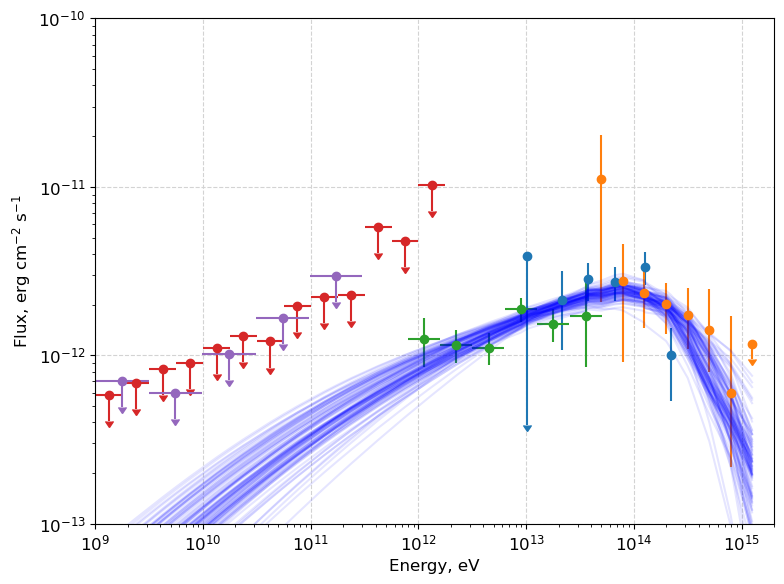

In [27]:
plt.figure(figsize=(8, 6))

for i, name in enumerate(names):
    plt.errorbar(e[i], f_cor[i], xerr=[e_l[i], e_p[i]], yerr=[f_l_cor[i], f_p_cor[i]],
                 fmt='o', linestyle='None', uplims=f_p_cor[i] <= 0,
                 color=Tab10[i], label=f' ')

set_plotting_defaults()
for i, res in enumerate(result_mod2):
    plt.plot(joint.photon_energy, ans[i], alpha=.1, color='blue')

plt.xscale('log')
plt.xlim(1e9, 2e15)
plt.xlabel("Energy, eV")
plt.yscale('log')
plt.ylim(1e-13, 1e-10)
plt.ylabel(r"Flux, $\mathrm{erg~cm^{-2}~s^{-1}}$")
plt.tight_layout()
# save_figure(f"electron_fit_mcmc_{bvalue * 1e6:.1f}uG")

plt.show()

In [28]:
print(np.mean(result_mod2, axis=0))
k = np.argmax(result_mod2[:, 3])
print(f"{joint.b2times[int(result_mod2[k, 3])]:.0f}")
print(result_mod2[k])
print(np.max(result_mod2, axis=0))
print(np.min(result_mod2, axis=0))

[-2.64339757e+00  1.71525384e+00  3.32236382e+00  5.39799854e+03]
1219 yr
[-2.95479588e+00  1.67311064e+00  3.97101502e+00  6.64632585e+03]
[-2.19599008e+00  1.83517182e+00  4.47708956e+00  6.64632585e+03]
[  -3.51645371    1.50299296    2.57770037 1494.0142836 ]


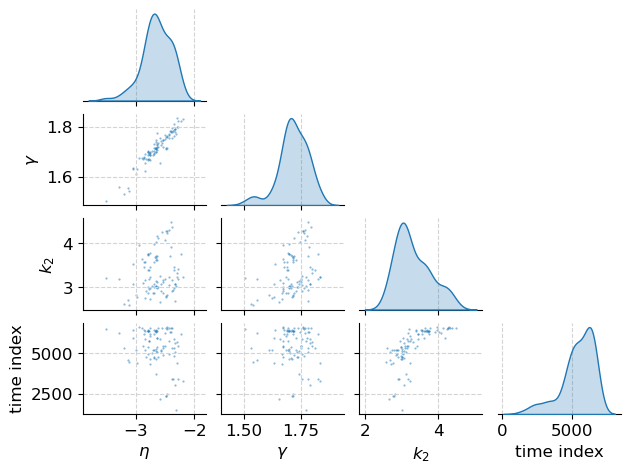

In [29]:
columns = [r"$\eta$", r"$\gamma$", r"$k_2$", r"time index"]
fs = pd.DataFrame(result_mod2, columns=columns)

g = sns.pairplot(fs, diag_kind="kde",
                plot_kws=dict(marker=".", linewidth=0, alpha=.5, s=10),
                corner=True, height=1.2, aspect=4/3)
# g.map_lower(sns.kdeplot, levels=5, color=".2", alpha=.3)
# save_figure(f"pairplot{nsteps}")
plt.show()

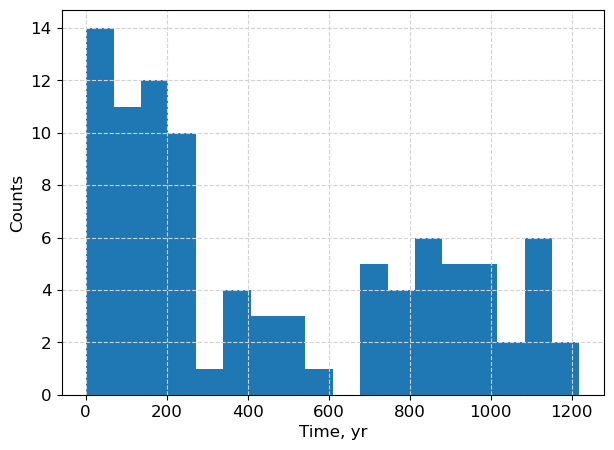

In [30]:
times = np.int_(result_mod2[:, 3])
plt.hist(joint.b2times[times], bins=18)

plt.xlabel(r"Time, yr")
plt.ylabel(r"Counts")
# plt.xlim(0, 10000)
plt.show()

In [31]:
from analysis_electrons.general_spectrum_analysis import volume_approximation, width_approximation, length_approximation

# calculate the synchrotron_emission
bfield = bvalue * Gauss
synch_photon_energy = np.logspace(-8, 15, 100) * u.eV
result_chosen = result_mod2


In [32]:
from spectrum.measurements_xray import constraint_XRISM, constraint_Chandra, weak_constraint_XRISM
from spectrum.Xrism_area_energy_dependence import xrism_in_out_ratio

In [33]:
norm_dA, dif_dA = xrism_in_out_ratio(joint.electron_energy)

106.4650843716541 pc


In [34]:
# SYNCHROTRON

path = os.path.join(SYNCH_INTERP_DIR, f"synch_power_interp_{bfield.value * 1e6:.1f}.pck")
synch_interp_data = pickle.load(open(path, "rb"))

synch_interp = synch_interp_data[2]

lg_ee = np.log10(joint.electron_energy.value)
lg_pe = np.log10(synch_photon_energy.value)
ee_pe, pe_ee = np.meshgrid(lg_ee, lg_pe, indexing='ij')
synch_table = 10**synch_interp((ee_pe, pe_ee)) * (1/u.s)

In [35]:
result_chosen = result_mod2
synch_flux_hom = np.zeros([result_chosen.shape[0], synch_photon_energy.size]) * flux_unit
synch_flux_dif = np.zeros([result_chosen.shape[0], synch_photon_energy.size]) * flux_unit
synch_flux_full = np.zeros([result_chosen.shape[0], synch_photon_energy.size]) * flux_unit

for i, res_i in enumerate(result_chosen):
    dN_dE = joint.cooled_spectrum(res_i)

    # Homogenous distribution of photons in the nebula
    dN_dE_XRISM1 = dN_dE * norm_dA
    synch_lum_hom = np.trapezoid(synch_table.T * dN_dE_XRISM1, joint.electron_energy, axis=1)
    synch_flux_hom[i] = synch_lum_hom * synch_photon_energy / joint.area

    # Purely diffusive electron distribution in the nebula
    dN_dE_XRISM2 = dN_dE * dif_dA
    synch_lum_dif = np.trapezoid(synch_table.T * dN_dE_XRISM2, joint.electron_energy, axis=1)
    synch_flux_dif[i] = synch_lum_dif * synch_photon_energy / joint.area

    # Total synchrotron emission
    synch_lum_full = np.trapezoid(synch_table.T * dN_dE, joint.electron_energy, axis=1)
    synch_flux_full[i] = synch_lum_full * synch_photon_energy / joint.area

In [36]:
uhe_photon_energy = np.logspace(8, 17, 100) * u.eV
_, joint.radiation_matrix = joint.set_radiation_matrix(electron_energy=joint.electron_energy,
                                                       photon_energy=uhe_photon_energy)
joint.photon_energy = uhe_photon_energy

In [37]:
from scipy.interpolate import splrep, splev

lg_phot_e = np.log10(uhe_photon_energy.value)
spectra = []
for i, res in enumerate(result_chosen):
    flux_bad = joint.model(res)
    spl = splrep(x=lg_phot_e, y=np.log10(flux_bad.value), s=0.1)
    flux = splev(lg_phot_e, spl)
    spectra.append(10**flux)

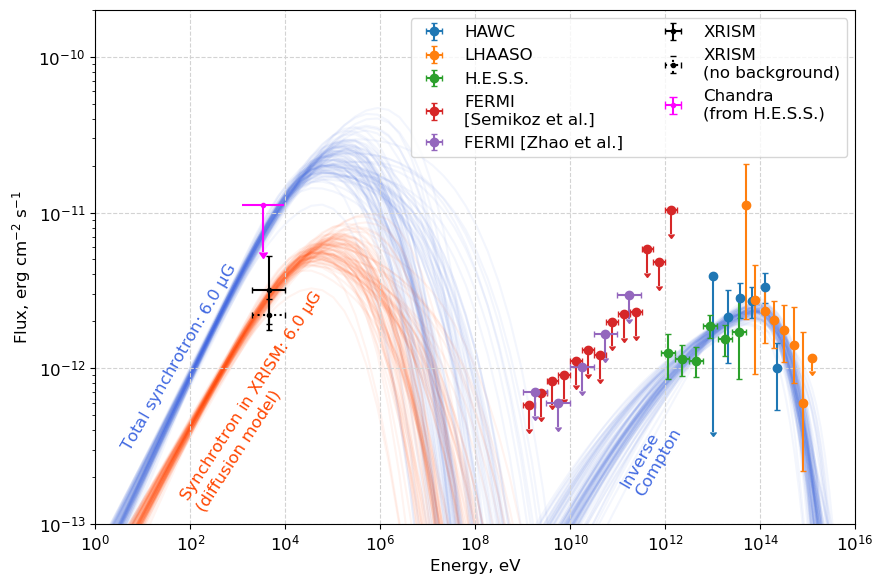

In [38]:
plt.figure(figsize=(9, 6))

# UHE spectrum
data = pickle.load(open(os.path.join(SPECTRUM_DIR, "UHE_spectrum_corrected.pck"), "rb"))
names, e, f_cor, f_l_cor, f_p_cor, e_l, e_p = data
names_short = ["HAWC", "LHAASO", "H.E.S.S.", "FERMI\n[Semikoz et al.]", "FERMI [Zhao et al.]"]
for i, name in enumerate(names):
    plt.errorbar(e[i], f_cor[i], xerr=[e_l[i], e_p[i]], yerr=[f_l_cor[i], f_p_cor[i]],
                 fmt='o', linestyle='None', uplims=f_p_cor[i] <= 0, capsize=2,
                 color=Tab10[i], label=names_short[i])
# X-Ray corrected
e, f, f_l, f_p, e_l, e_p = constraint_XRISM()
plt.errorbar(e, f, xerr=[e_l, e_p], yerr=[f_l, f_p], color='black', capsize=2,
             marker='o', markersize=3, label='XRISM', linestyle='None')
e, f, f_l, f_p, e_l, e_p = weak_constraint_XRISM()
eb = plt.errorbar(e, f, xerr=[e_l, e_p], yerr=[f_l, f_p], color='black', capsize=2,
                  marker='o', markersize=3, label='XRISM\n(no background)', linestyle='None')
eb[-1][0].set_linestyle(':')
e, f, f_l, f_p, e_l, e_p = constraint_Chandra()
plt.errorbar(e, f, xerr=[e_l, e_p], yerr=0.5 * f, uplims=True,
             marker='o', markersize=3, label='Chandra\n(from H.E.S.S.)', linestyle='None',
             color='magenta')
plt.errorbar(1, 1, linewidth=0, label=' ', marker=None)

g_a = .06
for i, res in enumerate(result_chosen[::]):
    if res[-1] < 1 or res[-2] > 4.2:
        continue
    # plot gamma-ray spectrum
    plt.plot(joint.photon_energy, spectra[i], alpha=g_a, color="royalblue", zorder=0)
    # plot synchrotron spectrum
    # plt.plot(synch_photon_energy, synch_flux_hom[i], alpha=g_a, color='seagreen', zorder=0)
    plt.plot(synch_photon_energy, synch_flux_dif[i], alpha=g_a, color='orangered', zorder=0)
    plt.plot(synch_photon_energy, synch_flux_full[i], alpha=g_a, color="royalblue", zorder=0)

# plt.text(2e1, 7e-13, f'D: {bvalue * 1e6:.1f} 'r'$\mathrm{\mu G}$', color='red', rotation=30)
# plt.text(2e1, 1.5e-13, f'H: {bvalue * 1e6:.1f} 'r'$\mathrm{\mu G}$', color='green', rotation=25)
plt.text(1e11, 1.5e-13, 'Inverse\nCompton', color='royalblue', rotation=60)
plt.text(3e0, 3e-13, f'Total synchrotron: {bvalue * 1e6:.1f} 'r'$\mathrm{\mu G}$', color='royalblue', rotation=60)
plt.text(5e1, 1.2e-13, f'Synchrotron in XRISM: {bvalue * 1e6:.1f} 'r'$\mathrm{\mu G}$'
                       '\n(diffusion model)', color='orangered', rotation=57)

plt.xscale('log')
plt.xlim(1e0, 1e16)
plt.xlabel("Energy, eV")

plt.yscale('log')
plt.ylim(1e-13, 2e-10)
plt.ylabel(r"Flux, $\mathrm{erg~cm^{-2}~s^{-1}}$")

plt.tight_layout()
plt.legend(loc=1, ncol=2)
plt.tight_layout()
save_figure("electrons_contant_emission_synch_6uG")
plt.show()